# Exploratory Data Analysis

--- Dataset Training Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None

--- Ringkasan Statistik Data Training ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


/tmp/ipykernel_16/1361122915.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df_train, palette='viridis')


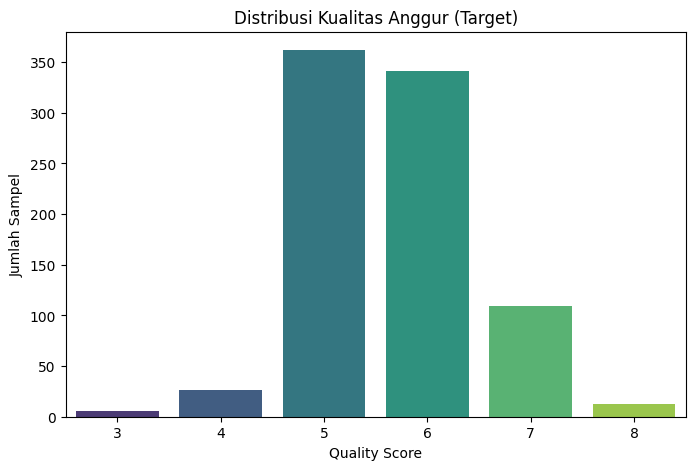

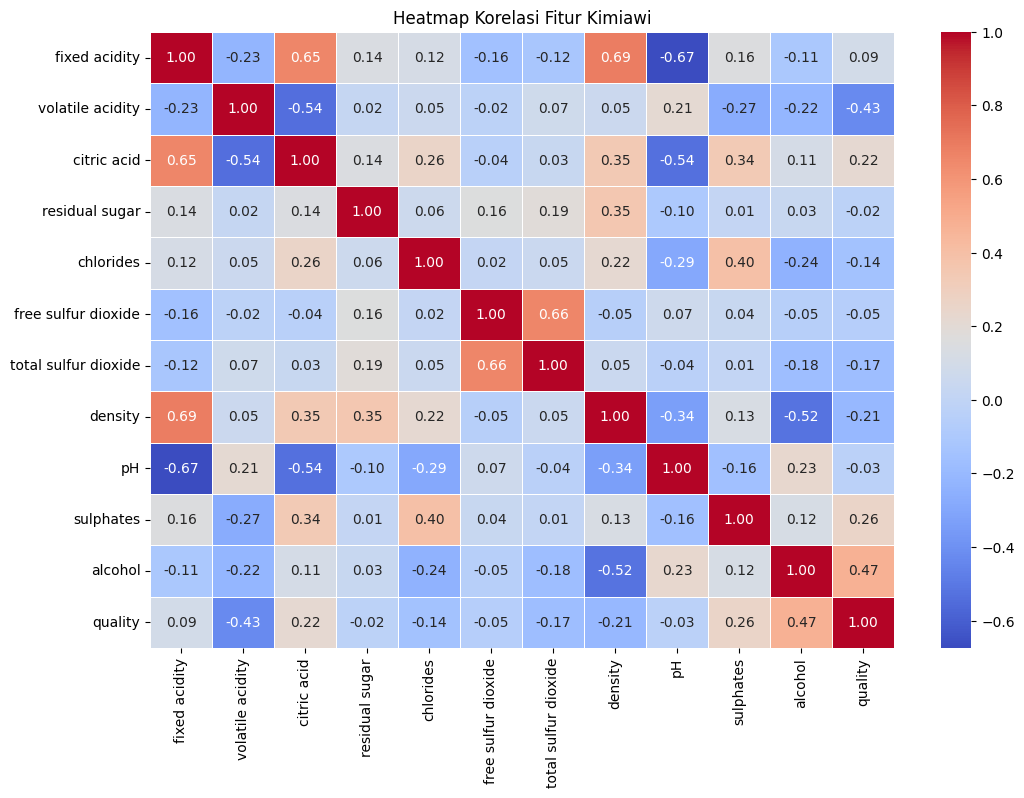

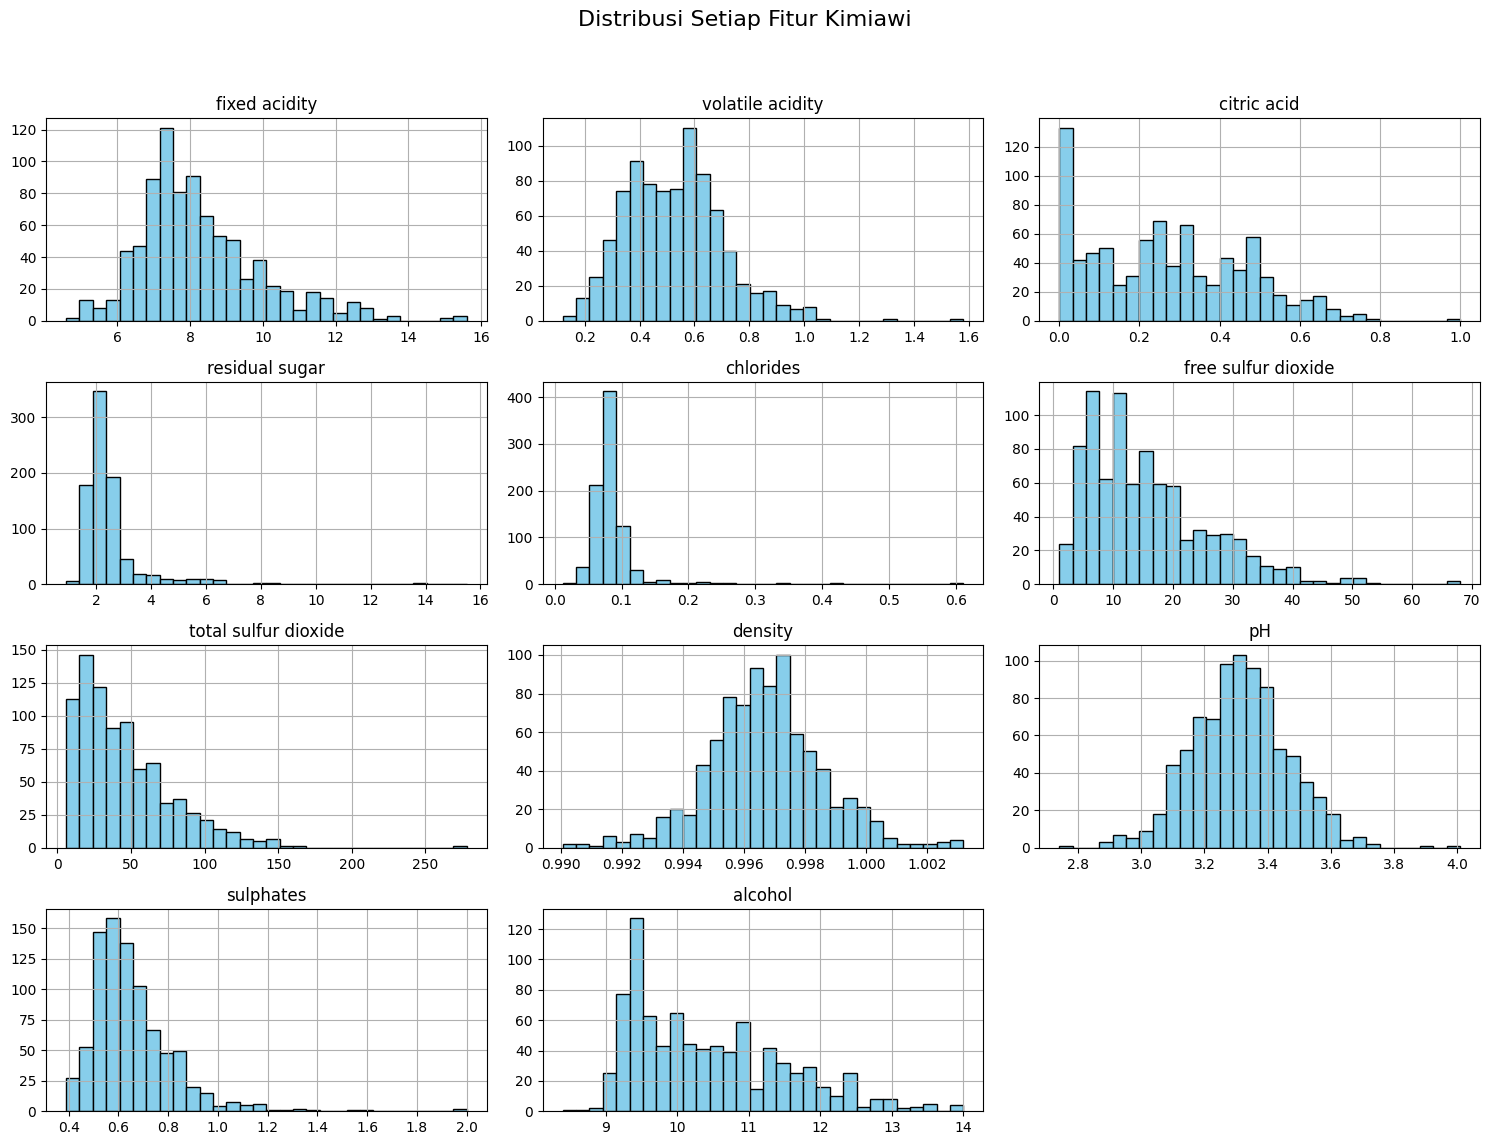

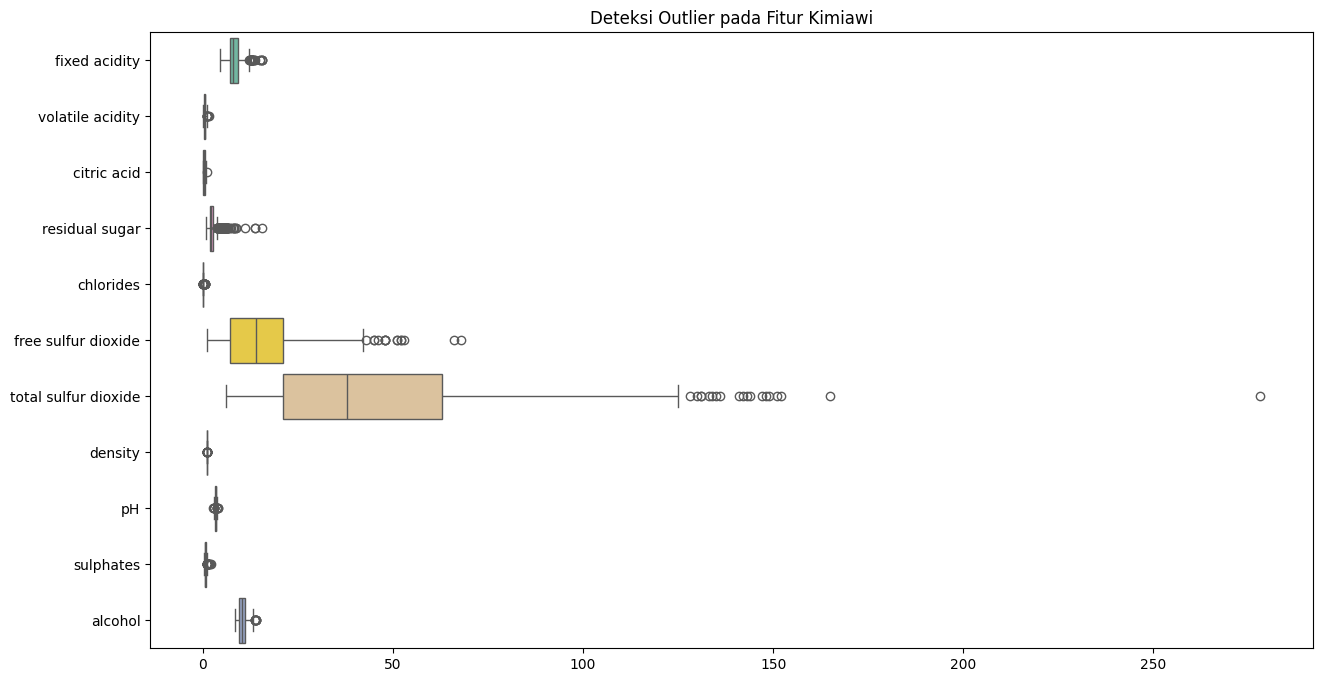

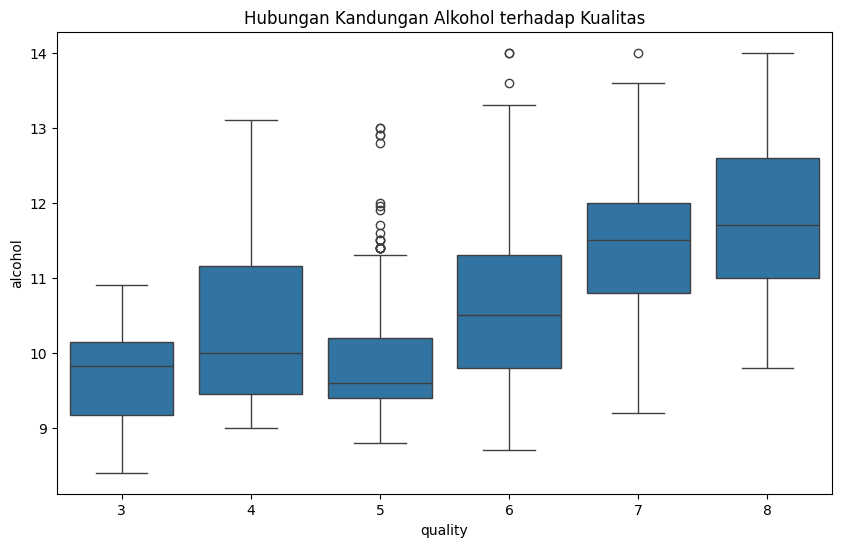

In [1]:
# =================================================================
# Tahap 1: Exploratory Data Analysis (EDA)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# Nama: Dimas Pasha Akrilian
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1.1 Memuat Dataset
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("--- Dataset Training Info ---")
print(df_train.info())

# 1.2 Ringkasan Statistik
# Memberikan gambaran umum mean, median, dan standar deviasi fitur kimiawi
print("\n--- Ringkasan Statistik Data Training ---")
display(df_train.describe())

# 1.3 Analisis Distribusi Target (Quality)
# Sangat penting untuk melihat ketidakseimbangan kelas (class imbalance)
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df_train, palette='viridis')
plt.title('Distribusi Kualitas Anggur (Target)')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Sampel')
plt.show()

# Interpretasi: Jika distribusi tidak merata, pertimbangkan teknik sampling 
# atau metrik evaluasi selain akurasi (seperti F1-Score)[cite: 1, 2].

# 1.4 Analisis Korelasi (Heatmap)
# Mencari hubungan linear antara fitur kimiawi dengan target 'quality'
plt.figure(figsize=(12, 8))
# Menghapus kolom 'Id' karena tidak memiliki nilai informasi statistik
correlation_matrix = df_train.drop(columns=['Id']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Kimiawi')
plt.show()

# 1.5 Distribusi Fitur (Histograms)
# Mengecek skewness (kemiringan) data dan rentang nilai untuk persiapan scaling
df_train.drop(columns=['Id', 'quality']).hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Setiap Fitur Kimiawi', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 1.6 Deteksi Outlier (Boxplots)
# Melihat adanya pencilan yang mungkin perlu di-handle saat data preparation[cite: 2]
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_train.drop(columns=['Id', 'quality']), orient='h', palette='Set2')
plt.title('Deteksi Outlier pada Fitur Kimiawi')
plt.show()

# 1.7 Hubungan Fitur Utama terhadap Kualitas
# Contoh: Melihat bagaimana kandungan Alcohol mempengaruhi Quality
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df_train)
plt.title('Hubungan Kandungan Alkohol terhadap Kualitas')
plt.show()

# Data Preparation

In [2]:
# =================================================================
# Tahap 2: Data Preparation
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2.1 Menghapus Kolom yang Tidak Relevan
# Kolom 'Id' tidak memiliki pengaruh terhadap kualitas anggur (target)
X = df_train.drop(columns=['Id', 'quality'])
y = df_train['quality']

# Simpan ID testing untuk kebutuhan pengumpulan hasil akhir nanti
test_id = df_test['Id']
X_test = df_test.drop(columns=['Id'])

print(f"Jumlah fitur yang akan digunakan: {X.shape[1]}")

# 2.2 Feature Scaling
# Mengapa perlu scaling? 
# Berdasarkan EDA, rentang 'total sulfur dioxide' jauh lebih besar dibanding 'pH' atau 'chlorides'.
# Tanpa scaling, model (seperti KNN atau SVM) akan menganggap fitur dengan angka besar lebih penting.

scaler = StandardScaler()

# Fit pada data training dan transform baik data training maupun testing
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame agar tetap mudah dibaca
X_prepared = pd.DataFrame(X_scaled, columns=X.columns)
X_test_prepared = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("--- Contoh Data Setelah Scaling ---")
display(X_prepared.head())

# 2.3 Split Data (Internal Validation)
# Walaupun kita akan menggunakan K-Fold nanti, kita tetap butuh set evaluasi awal
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_prepared, y, test_size=0.2, random_state=42, stratify=y
)

# Catatan: 'stratify=y' digunakan untuk menjaga rasio kelas target tetap sama 
# karena data kita memiliki class imbalance.

print(f"Data Training: {X_train_final.shape}")
print(f"Data Validasi: {X_val.shape}")

Jumlah fitur yang akan digunakan: 11
--- Contoh Data Setelah Scaling ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.565527,1.176198,-0.960627,-0.623616,0.147259,-0.561759,-0.030890,-0.490363,-0.480901,-0.936887,-0.591119
1,-0.095215,0.254705,-0.242789,-0.314200,-0.201873,-0.367478,0.600550,0.004342,-0.151932,-0.877102,-1.153787
2,1.080565,-0.555092,0.680145,0.072570,0.106185,-0.270338,0.190114,0.867443,-0.612489,-0.099897,-0.403563
3,2.726657,-0.164156,1.449257,0.227278,-0.304559,-0.853180,-0.693903,1.804225,-1.467809,0.139242,0.440439
4,0.081152,-0.946029,0.269952,-0.236846,-0.119725,1.575327,1.042558,-0.153543,-0.086138,0.378382,0.534217


Data Training: (685, 11)
Data Validasi: (172, 11)


# Feature Engineering

/tmp/ipykernel_16/4069983374.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


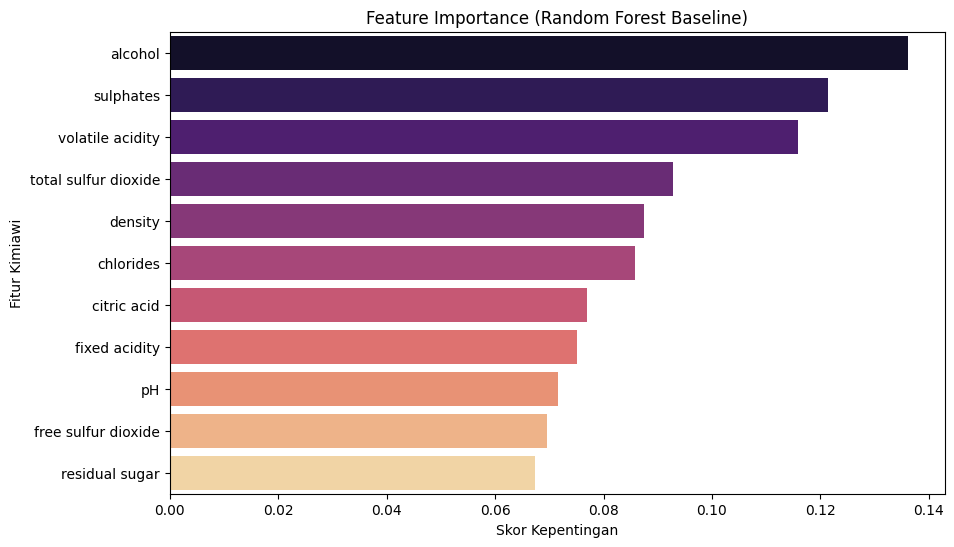

Fitur yang disarankan untuk di-prune: []
Jumlah fitur akhir setelah pruning: 11


In [3]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 3.1 Menghitung Feature Importance
# Kita gunakan Random Forest sebagai model dasar untuk melihat fitur mana yang paling dominan.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_final, y_train_final)

# Mendapatkan skor kepentingan fitur
importances = rf_selector.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3.2 Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest Baseline)')
plt.xlabel('Skor Kepentingan')
plt.ylabel('Fitur Kimiawi')
plt.show()

# 3.3 Fitur Pruning (Penghapusan Fitur)
# Berdasarkan grafik, kita bisa menentukan ambang batas (threshold).
# Jika ada fitur dengan kepentingan sangat rendah (misal < 0.05), kita bisa menghapusnya.

# Contoh: Kita asumsikan semua fitur di dataset ini cukup relevan, 
# namun jika anda ingin bereksperimen menghapus fitur terendah:
threshold = 0.04  # Sesuaikan berdasarkan hasil grafik anda
low_importance_features = feature_importance_df[feature_importance_df['Importance'] < threshold]['Feature'].tolist()

print(f"Fitur yang disarankan untuk di-prune: {low_importance_features}")

# Eksekusi Pruning (Opsional: jalankan baris di bawah jika ada fitur yang ingin dibuang)
# X_train_final = X_train_final.drop(columns=low_importance_features)
# X_val = X_val.drop(columns=low_importance_features)
# X_test_prepared = X_test_prepared.drop(columns=low_importance_features)

print(f"Jumlah fitur akhir setelah pruning: {X_train_final.shape[1]}")

# Fitur Pruning

In [4]:
# =================================================================
# Tahap 4: Fitur Pruning
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

# 4.1 Menentukan Threshold Pruning
# Berdasarkan analisis feature importance sebelumnya, kita tentukan batas bawah.
# Kita akan menghapus fitur yang kontribusinya di bawah threshold tertentu.
threshold_pruning = 0.05  # Contoh: fitur dengan kepentingan < 5% akan dihapus

# Identifikasi fitur yang memiliki kepentingan di bawah ambang batas
features_to_drop = feature_importance_df[feature_importance_df['Importance'] < threshold_pruning]['Feature'].tolist()

print(f"Fitur yang diidentifikasi untuk dihapus: {features_to_drop}")

# 4.2 Eksekusi Penghapusan Fitur (Pruning)
# Kita hapus fitur tersebut dari semua set data (training, validasi, dan testing)
X_train_pruned = X_train_final.drop(columns=features_to_drop)
X_val_pruned = X_val.drop(columns=features_to_drop)
X_test_pruned = X_test_prepared.drop(columns=features_to_drop)

# 4.3 Verifikasi Hasil Akhir
print("\n--- Ringkasan Setelah Fitur Pruning ---")
print(f"Jumlah fitur awal: {X_train_final.shape[1]}")
print(f"Jumlah fitur yang dihapus: {len(features_to_drop)}")
print(f"Jumlah fitur akhir: {X_train_pruned.shape[1]}")

print("\nFitur yang tersisa:")
print(X_train_pruned.columns.tolist())

# Tampilkan 5 baris pertama data yang sudah siap untuk modeling
display(X_train_pruned.head())

Fitur yang diidentifikasi untuk dihapus: []

--- Ringkasan Setelah Fitur Pruning ---
Jumlah fitur awal: 11
Jumlah fitur yang dihapus: 0
Jumlah fitur akhir: 11

Fitur yang tersisa:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
177,0.433886,1.427515,-0.140241,-0.623616,-0.181336,-0.561759,-0.788619,0.120124,-0.151932,0.079457,-0.403563
505,-0.624316,1.092426,-1.114450,1.658328,-0.017038,-1.144600,-1.104339,-0.258799,0.637594,-1.594521,0.440439
17,-0.330371,-0.220004,-0.037693,-0.468908,-0.509932,-0.658899,-0.472899,-0.048286,0.506006,-0.099897,-0.778675
738,-0.154004,-0.834333,0.885242,-0.468908,0.229408,-0.950320,-0.978051,-0.574568,-0.086138,-0.099897,0.909329
236,-0.506738,0.282629,-1.370820,-0.391554,-0.468857,-0.853180,-1.104339,-0.564042,0.900769,-0.458607,0.815551


# K-Fold Validation

In [5]:
# =================================================================
# Tahap 5: K-Fold Validation
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 5.1 Inisialisasi Stratified K-Fold
# Kita menggunakan Stratified karena distribusi kelas 'quality' tidak seimbang.
# Stratified memastikan rasio kelas di setiap fold tetap terjaga sesuai data asli.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5.2 Inisialisasi Model Baseline
# Menggunakan Random Forest dengan parameter default sebagai acuan awal.
model_baseline = RandomForestClassifier(random_state=42)

# 5.3 Melakukan Cross Validation
# Kita evaluasi model menggunakan data yang sudah di-prune (X_train_pruned).
cv_scores = cross_val_score(
    model_baseline, 
    X_train_pruned, 
    y_train_final, 
    cv=skf, 
    scoring='accuracy'
)

# 5.4 Menampilkan Hasil Evaluasi
print("--- Hasil K-Fold Validation (Accuracy) ---")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nRata-rata Akurasi: {np.mean(cv_scores):.4f}")
print(f"Standar Deviasi: {np.std(cv_scores):.4f}")

# Interpretasi: Standar deviasi yang rendah menunjukkan model Anda stabil 
# dan tidak terlalu sensitif terhadap perubahan data training[cite: 2].

--- Hasil K-Fold Validation (Accuracy) ---
Fold 1: 0.6423
Fold 2: 0.6204
Fold 3: 0.6569
Fold 4: 0.6496
Fold 5: 0.6204

Rata-rata Akurasi: 0.6380
Standar Deviasi: 0.0150


# Pseudo-Labeling

In [6]:
# =================================================================
# Tahap 6: Pseudo-Labeling
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# 6.1 Melatih Model Awal (Teacher Model)
# Kita gunakan model yang kuat untuk menebak label di data testing.
# Sesuaikan jumlah kelas (n_classes) karena target 'quality' berkisar 3-8.
# Kita perlu melakukan label encoding jika target tidak dimulai dari 0.
y_shifted = y_train_final - y_train_final.min() # Menggeser label agar mulai dari 0

teacher_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
teacher_model.fit(X_train_pruned, y_shifted)

# 6.2 Prediksi Probabilitas pada Data Testing
# Kita mencari baris data di X_test_pruned yang model sangat yakin hasilnya.
test_probs = teacher_model.predict_proba(X_test_pruned)
max_probs = np.max(test_probs, axis=1)
pseudo_labels = np.argmax(test_probs, axis=1)

# 6.3 Menentukan Ambang Batas Kepercayaan (Threshold)
# Ambil hanya data yang tingkat keyakinannya > 85% untuk menjaga kualitas data.
confidence_threshold = 0.85
high_confidence_idx = np.where(max_probs >= confidence_threshold)[0]

# 6.4 Membuat Dataset Pseudo-Labeled
X_pseudo = X_test_pruned.iloc[high_confidence_idx]
y_pseudo = pseudo_labels[high_confidence_idx] + y_train_final.min() # Kembalikan ke skala asli

print(f"Jumlah sampel testing yang dijadikan Pseudo-Label: {len(X_pseudo)}")

# 6.5 Menggabungkan Data Training Asli dengan Pseudo-Label
X_train_augmented = pd.concat([X_train_pruned, X_pseudo], axis=0)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo)], axis=0)

print(f"Total Data Training Baru (Original + Pseudo): {X_train_augmented.shape[0]}")

# Verifikasi distribusi kelas baru
print("\nDistribusi Kualitas Setelah Augmentasi:")
print(y_train_augmented.value_counts())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:49:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Jumlah sampel testing yang dijadikan Pseudo-Label: 161
Total Data Training Baru (Original + Pseudo): 846

Distribusi Kualitas Setelah Augmentasi:
5    377
6    333
7     99
4     22
8     10
3      5
Name: count, dtype: int64


# Training Model dan Optuna 

In [7]:
!pip install optuna -q

In [8]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

# 7.2.1 Persiapan Label
# XGBoost memerlukan label mulai dari 0. Kita gunakan y_train_augmented dari tahap sebelumnya.
min_label = y_train_augmented.min()
y_train_shifted = y_train_augmented - min_label

# 7.2.2 Definisikan Fungsi Objektif Optuna
def objective(trial):
    # Menentukan rentang hyperparameter yang akan dicari
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss'
    }
    
    # Inisialisasi Model dengan parameter dari Optuna
    model = XGBClassifier(**param)
    
    # Gunakan K-Fold Validation untuk mendapatkan skor yang stabil
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_augmented, y_train_shifted, cv=cv, scoring='accuracy').mean()
    
    return score

# 7.2.3 Menjalankan Studi Optuna
print("--- Memulai Optimasi Hyperparameter dengan Optuna ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Anda bisa menaikkan n_trials menjadi 100 untuk hasil maksimal

print("\n--- Hasil Optimasi ---")
print(f"Skor Akurasi Terbaik: {study.best_value:.4f}")
print("Parameter Terbaik:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 7.2.4 Melatih Model Final dengan Parameter Terbaik
best_params = study.best_params
best_params['random_state'] = 42
best_params['use_label_encoder'] = False
best_params['eval_metric'] = 'mlogloss'

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_augmented, y_train_shifted)

print("\nModel Final Berhasil Dilatih!")

[I 2026-05-02 15:49:11,637] A new study created in memory with name: no-name-29ea6e2f-f277-4e1c-9747-842cdf774796


--- Memulai Optimasi Hyperparameter dengan Optuna ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:49:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:49:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:49:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


--- Hasil Optimasi ---
Skor Akurasi Terbaik: 0.7258
Parameter Terbaik:
  n_estimators: 706
  max_depth: 8
  learning_rate: 0.14197287952504647
  subsample: 0.8668158901858078
  colsample_bytree: 0.715984214640909
  gamma: 0.3752261613135205

Model Final Berhasil Dilatih!


# Evaluasi Akhir 

--- Evaluasi Model Final (Internal Validation) ---
Akurasi pada Data Validasi: 61.63%
F1-Score (Weighted): 0.5999

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.75      0.70        73
           6       0.58      0.62      0.60        68
           7       0.62      0.36      0.46        22
           8       1.00      0.33      0.50         3

    accuracy                           0.62       172
   macro avg       0.47      0.34      0.38       172
weighted avg       0.60      0.62      0.60       172



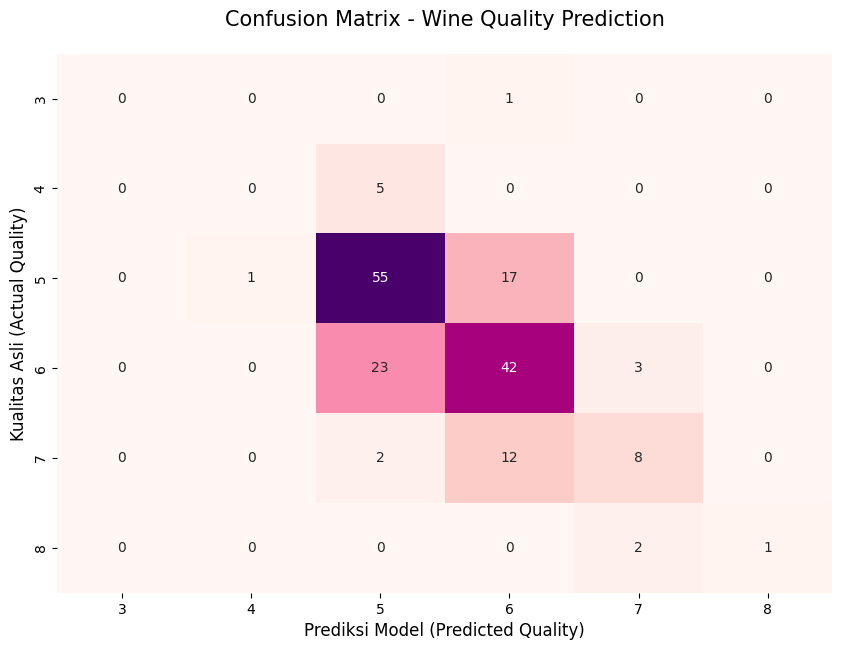

In [9]:
# =================================================================
# Tahap 8: Evaluasi Akhir (REVISI)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 8.1 Melakukan Prediksi pada Data Validasi
# Pastikan X_val_pruned adalah data yang belum pernah dilihat model saat 'fit'
y_pred_val_shifted = final_model.predict(X_val_pruned)

# 8.2 Mengembalikan Skala Label (Reverse Shift)
# Mengembalikan label 0-indexed (hasil XGBoost) ke label asli anggur (misal: 3-8)
y_pred_val = y_pred_val_shifted + min_label

# 8.3 Menghitung Metrik Utama
val_accuracy = accuracy_score(y_val, y_pred_val)
# Menggunakan weighted F1-score karena adanya ketidakseimbangan kelas pada data wine
val_f1 = f1_score(y_val, y_pred_val, average='weighted')

print(f"--- Evaluasi Model Final (Internal Validation) ---")
print(f"Akurasi pada Data Validasi: {val_accuracy * 100:.2f}%")
print(f"F1-Score (Weighted): {val_f1:.4f}\n")

# 8.4 Menampilkan Classification Report Lengkap
# zero_division=0 memastikan tidak ada error jika ada kelas yang tidak terprediksi
print("Classification Report:")
print(classification_report(y_val, y_pred_val, zero_division=0))

# 8.5 Visualisasi Confusion Matrix dengan Persentase
cm = confusion_matrix(y_val, y_pred_val)
labels = sorted(y_val.unique())

plt.figure(figsize=(10, 7))
# Menampilkan angka absolut dan normalisasi (persentase) agar lebih mudah dibaca
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=labels, 
            yticklabels=labels,
            cbar=False)

plt.title('Confusion Matrix - Wine Quality Prediction', fontsize=15, pad=20)
plt.xlabel('Prediksi Model (Predicted Quality)', fontsize=12)
plt.ylabel('Kualitas Asli (Actual Quality)', fontsize=12)
plt.show()

# Prediksi Data Uji (Testing)

In [10]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing)
# Proyek: Klasifikasi Kualitas Anggur (UTS PDAB 2026)
# =================================================================

# 9.1 Melakukan Prediksi pada Data Testing
# Pastikan menggunakan data X_test_pruned yang fiturnya sudah sesuai dengan model
y_test_pred_shifted = final_model.predict(X_test_pruned)

# 9.2 Mengembalikan Skala Label (Reverse Shift)
# Mengubah kembali label 0-indexed menjadi skala kualitas asli (3-8)
y_test_pred = y_test_pred_shifted + min_label

# 9.3 Membuat DataFrame Hasil Prediksi
# Format harus sesuai permintaan: Hanya kolom 'Id' dan 'quality'
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_test_pred
})

# 9.4 Menyimpan Hasil ke File CSV
# Nama file menggunakan 3 digit terakhir NIM Anda (026)
file_output = 'hasilprediksi_026.csv'
submission_df.to_csv(file_output, index=False)

print(f"--- Proses Selesai ---")
print(f"File '{file_output}' berhasil dibuat.")
print(f"Jumlah baris prediksi: {submission_df.shape[0]}")

# 9.5 Verifikasi Format File
print("\nContoh isi file hasil prediksi:")
display(submission_df.head())

--- Proses Selesai ---
File 'hasilprediksi_026.csv' berhasil dibuat.
Jumlah baris prediksi: 286

Contoh isi file hasil prediksi:


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6
